In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"C:\Users\tange\Downloads\ai4i2020.csv")

In [8]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df = df.drop(['UDI', 'Product ID'], axis=1)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

In [11]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [12]:
df['Temp_Difference'] = (
    df['Process temperature [K]']
    - df['Air temperature [K]']
)

In [13]:
df[['Air temperature [K]',
    'Process temperature [K]',
    'Temp_Difference']].head()

,Air temperature [K],Process temperature [K],Temp_Difference
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [14]:
df['Power_Index'] = (
    df['Rotational speed [rpm]']
    * df['Torque [Nm]']
)

In [15]:
df[['Rotational speed [rpm]',
    'Torque [Nm]',
    'Power_Index']].head()

,Rotational speed [rpm],Torque [Nm],Power_Index
0,1551,42.8,66382.8
1,1408,46.3,65190.4
2,1498,49.4,74001.2
3,1433,39.5,56603.5
4,1408,40.0,56320.0


In [16]:
df['Wear_Torque'] = (
    df['Tool wear [min]']
    * df['Torque [Nm]']
)

In [17]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temp_Difference',
       'Power_Index', 'Wear_Torque'],
      dtype='object')

In [18]:
X = df.drop('Machine failure', axis=1)

y = df['Machine failure']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_v2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
from sklearn.metrics import accuracy_score

pred_v2 = model_v2.predict(X_test)

accuracy_v2 = accuracy_score(y_test, pred_v2)

print("New Accuracy =", accuracy_v2)

New Accuracy = 0.999


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_v2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_v2.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                    Feature  Importance
7                       HDF    0.251485
9                       OSF    0.174032
8                       PWF    0.125182
6                       TWF    0.101246
12              Power_Index    0.096066
13              Wear_Torque    0.069926
4               Torque [Nm]    0.052908
3    Rotational speed [rpm]    0.047023
11          Temp_Difference    0.038429
5           Tool wear [min]    0.021558
1       Air temperature [K]    0.010537
2   Process temperature [K]    0.007547
0                      Type    0.003817
10                      RNF    0.000243


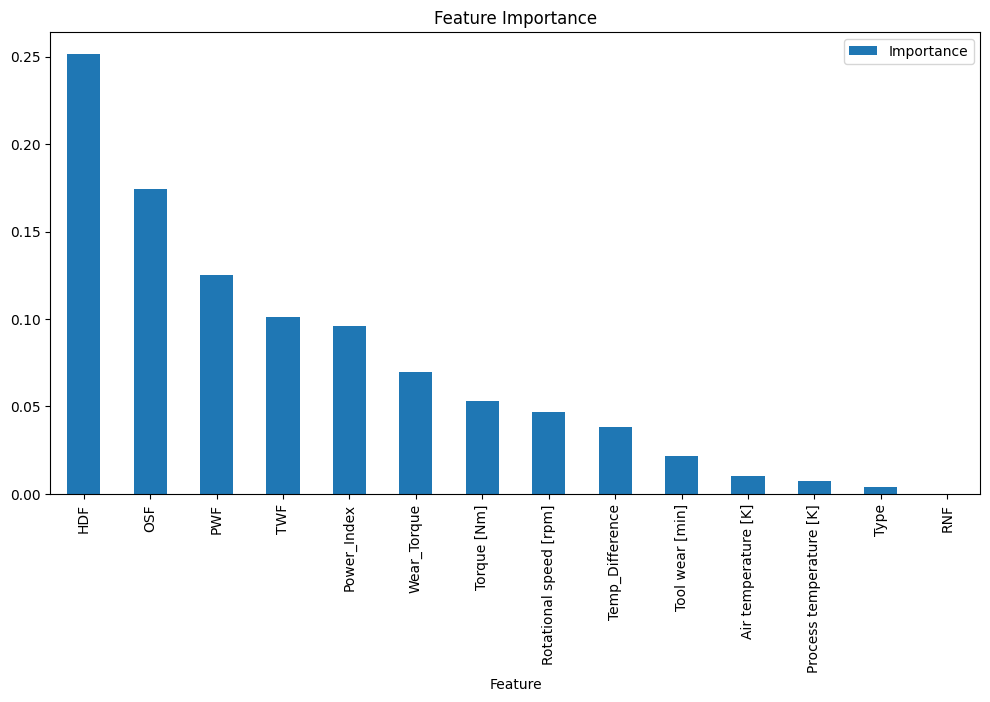

In [24]:
importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(12,6)
)

plt.title("Feature Importance")
plt.show()

In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_v2.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                    Feature  Importance
7                       HDF    0.251485
9                       OSF    0.174032
8                       PWF    0.125182
6                       TWF    0.101246
12              Power_Index    0.096066
13              Wear_Torque    0.069926
4               Torque [Nm]    0.052908
3    Rotational speed [rpm]    0.047023
11          Temp_Difference    0.038429
5           Tool wear [min]    0.021558
1       Air temperature [K]    0.010537
2   Process temperature [K]    0.007547
0                      Type    0.003817
10                      RNF    0.000243


In [26]:
from sklearn.metrics import f1_score, confusion_matrix


pred_v2 = model_v2.predict(X_test)


macro_f1 = f1_score(
    y_test,
    pred_v2,
    average="macro"
)


print("Macro F1 Score:", macro_f1)


print(
    confusion_matrix(
        y_test,
        pred_v2
    )
)

Macro F1 Score: 0.9914089347079038
[[1939    0]
 [   2   59]]


In [29]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import shap


explainer = shap.TreeExplainer(
    model_v2
)


shap_values = explainer.shap_values(
    X_test
)

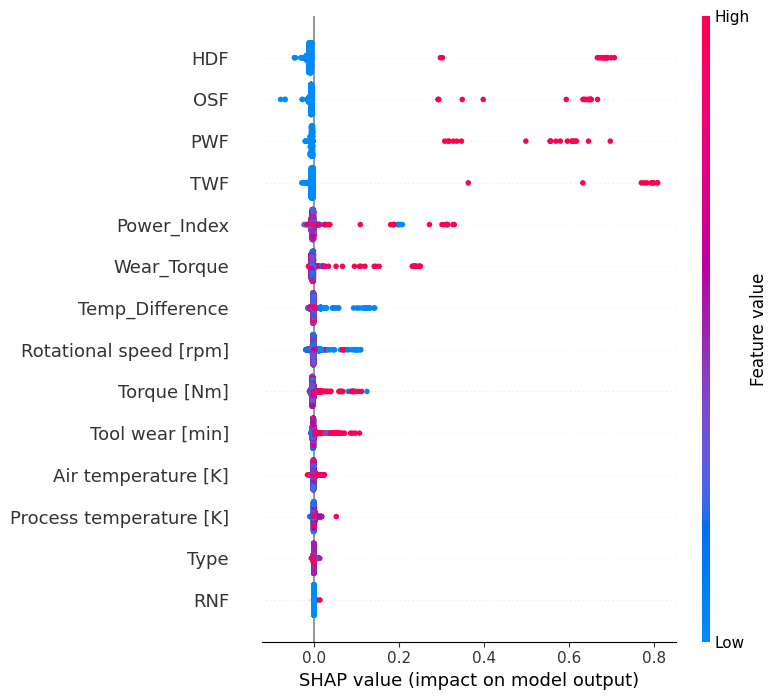

In [35]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

In [37]:
import shap

shap.initjs()

In [38]:
index = 5

shap.plots.force(
    explainer.expected_value[1],
    shap_values[index, :, 1],
    X_test.iloc[index]
)

In [39]:
import matplotlib.pyplot as plt

plt.savefig(
    "shap_summary_plot.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## SHAP Analysis Insights

- Tool wear, torque, and temperature-related features have a major impact on machine failure prediction.
- Higher values of important sensor features increase the probability of failure.
- SHAP helps explain individual predictions and improves model interpretability.